--2025-12-12 12:10:55--  https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.20.207, 108.177.98.207, 74.125.135.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.20.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘/tmp/rps.zip’

/tmp/rps.zip        100%[===================>] 191.38M   273MB/s    in 0.7s    

2025-12-12 12:10:56 (273 MB/s) - ‘/tmp/rps.zip’ saved [200682221/200682221]

--2025-12-12 12:10:56--  https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.20.207, 108.177.98.207, 74.125.135.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.20.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘/tmp/rps-test-se

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,978,883 (57.14 MB)

 Trainable params: 264,195 (1.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 779ms/step - accuracy: 0.4339 - loss: 1.1576 - val_accuracy: 0.6687 - val_loss: 0.7192
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 591ms/step - accuracy: 0.7214 - loss: 0.6691 - val_accuracy: 0.8651 - val_loss: 0.4808
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 591ms/step - accuracy: 0.8184 - loss: 0.4727 - val_accuracy: 0.8750 - val_loss: 0.3789
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 595ms/step - accuracy: 0.8449 - loss: 0.3950 - val_accuracy: 0.9087 - val_loss: 0.3140
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 592ms/step - accuracy: 0.8696 - loss: 0.3285 - val_accuracy: 0.8413 - val_loss: 0.3591
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 594ms/step - accuracy: 0.8877 - loss: 0.2931 - val_accuracy: 0.8968 - val_loss: 0.2912
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 590ms/step - accuracy: 0.9009 - loss: 0.2689 - val_accuracy: 0.9167 - val_loss: 0.2473
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 599ms/step - accuracy: 0.9174 - loss: 0.2543 - val_accu

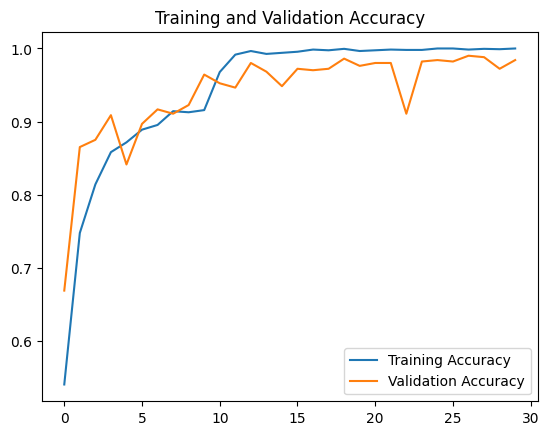

In [ ]:
import tensorflow as tf #for building and training deep learning models
import os #Provides functions for interacting with the operating system (paths, directories).
import zipfile #Used to extract downloaded ZIP datasets.
import matplotlib.pyplot as plt #Used to plot training and validation accuracy graphs.
from tensorflow.keras.preprocessing.image import ImageDataGenerator #Loads images from directories and applies preprocessing and augmentation.
from tensorflow.keras.applications import VGG16 #Imports the pre-trained VGG16 model.
from tensorflow.keras import layers, models, optimizers #Provides tools to build, compile, and optimize neural networks

# Step 1: Download and extract the dataset automatically
!wget --no-check-certificate https://storage.googleapis.com/download.tensorflow.org/data/rps.zip -O /tmp/rps.zip #download the rps training dataset
!wget --no-check-certificate https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip -O /tmp/rps-test-set.zip #download the rps test set

# Extract training set
with zipfile.ZipFile('/tmp/rps.zip', 'r') as zip_ref: #Extracts the training images into the /tmp/rps directory
    zip_ref.extractall('/tmp/')

# Extract test set
with zipfile.ZipFile('/tmp/rps-test-set.zip', 'r') as zip_ref: #Extracts the test images into the /tmp/rps directory
    zip_ref.extractall('/tmp/')

# Dataset paths (after extraction: /tmp/rps/rock, /tmp/rps/paper, etc.)
train_dir = '/tmp/rps' #Specifies the directory containing training images
test_dir = '/tmp/rps-test-set' #Specifies the directory containing test images

# Step 2: Data augmentation and generators
IMG_SIZE = (224, 224)  # VGG16 expects 224x224 and Resizes images to 224×224 pixels as required by VGG16.
BATCH_SIZE = 32 #Processes 32 images at a time during training

 #Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalizes pixel values to the range [0, 1].
    rotation_range=40, #Randomly rotates images to improve robustness
    width_shift_range=0.2,
    height_shift_range=0.2, # randomly shifts images horizontally and vertically.
    shear_range=0.2, #applies shearing transformations
    zoom_range=0.2, #randomly zoom images in and out
    horizontal_flip=True, #randomly flips image horizontally
    fill_mode='nearest', #fills empty pixels created by transformations
    validation_split=0.2  # 20% for validation
)

train_generator = train_datagen.flow_from_directory( #loads training images from directory
    train_dir,
    target_size=IMG_SIZE, #resize all images 224x224
    batch_size=BATCH_SIZE, #loads images in batch of 32
    class_mode='categorical', #uses one hot encoding for class labels
    subset='training' #specifies training subset
)

val_generator = train_datagen.flow_from_directory( #loads validation images from the same directory
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation' #specifies validation set
)

test_datagen = ImageDataGenerator(rescale=1./255) #normalizes test images without augmentation
test_generator = test_datagen.flow_from_directory( #loads test images
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False #disables shuffling to preserve label order during evaluation
)

# Load VGG16 pre-trained model (feature extraction)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base and Freezes all VGG16 layers (feature extraction).

# Build the model
model = models.Sequential([ #creates a sequential neural network
    base_model, #Adds the pre-trained VGG16 model
    layers.GlobalAveragePooling2D(), #reduces spatial dimensions and prevents overfitting
    layers.Dropout(0.5), #Randomly disables neurons to improve generalization
    layers.Dense(512, activation='relu'), #Adds a fully connected layer for learning task-specific features
    layers.Dropout(0.5),#further reduces overfitting
    layers.Dense(3, activation='softmax')  # 3 classes: rock, paper, scissors
])

model.summary()

# Compile
model.compile(optimizer='adam', #use adam optimizer for efficient learning
              loss='categorical_crossentropy', #use loss functionfor multiclass classification
              metrics=['accuracy'])

# Step 4: Train with feature extraction (10 epochs)
history_feat = model.fit( #starts training the model
    train_generator,
    epochs=10, #trains 10 epochs
    validation_data=val_generator #Validates model performance after each epoch
)

# Step 5: Fine-tuning (unfreeze top layers of VGG16)
base_model.trainable = True

# Freeze all layers except the last few (fine-tune only top layers)
for layer in base_model.layers[:-20]:  # Freezes lower layers and fine-tunes only the top 20 layers. (VGG16 model)
    layer.trainable = False

# Re-compile with lower learning rate
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), #uses a lower learning rate to avoid large weight updates
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train more (fine-tuning) (Fine tuning training)
history_fine = model.fit(
    train_generator,
    epochs=20,  # More epochs for fine-tuning
    validation_data=val_generator
)

# Step 6: Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator) #evaluates model performance on unseen test data
print(f"\nTest Accuracy: {test_acc * 100:.2f}%") #print the final test accuracy

# Optional: Plot training history
acc = history_feat.history['accuracy'] + history_fine.history['accuracy'] #combines accuracy from both training phases
val_acc = history_feat.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.plot(acc, label='Training Accuracy') #plots training accuracy
plt.plot(val_acc, label='Validation Accuracy') #plots validation accuracy
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 479ms/step


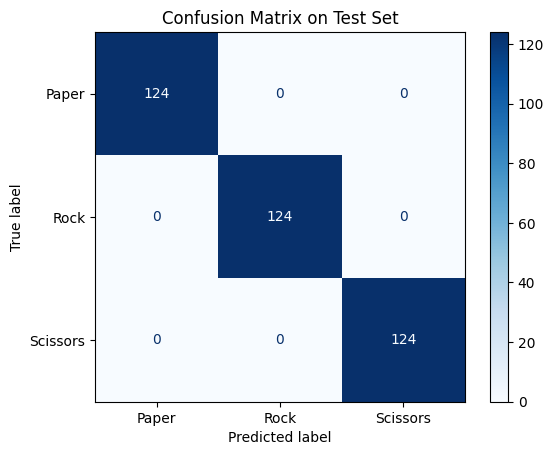

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions on test set
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paper', 'Rock', 'Scissors'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.show()